<a href="https://colab.research.google.com/github/SanjanaRitika/TextToCode_seq2seq/blob/main/final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip uninstall -y fsspec gcsfs
!pip install -q datasets sacrebleu fsspec gcsfs

Found existing installation: fsspec 2025.3.0
Uninstalling fsspec-2025.3.0:
  Successfully uninstalled fsspec-2025.3.0
Found existing installation: gcsfs 2025.3.0
Uninstalling gcsfs-2025.3.0:
  Successfully uninstalled gcsfs-2025.3.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 16.8 MB/s eta 0:00:00


Imports + Seed + Device

In [7]:
import random, re, math, time
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
import sacrebleu

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


Config

In [8]:
@dataclass
class CFG:
    TRAIN_SIZE: int = 10000
    VAL_SIZE: int   = 1000
    TEST_SIZE: int  = 1000

    MAX_SRC_LEN: int = 50
    MAX_TGT_LEN: int = 80

    BATCH_SIZE: int = 64
    EPOCHS: int = 10
    LR: float = 2e-3
    CLIP_NORM: float = 1.0

    EMB_DIM: int = 256
    HID_DIM: int = 256
    DROPOUT: float = 0.2

    # Teacher forcing schedule
    TF_START: float = 0.7
    TF_END: float   = 0.3

    # Label smoothing helps generalization + BLEU
    LABEL_SMOOTHING: float = 0.1

    MAX_DECODE_LEN: int = 90

cfg = CFG()

Tokenizer

In [9]:
SPECIALS = ["<pad>", "<unk>", "<bos>", "<eos>"]
PAD, UNK, BOS, EOS = SPECIALS

def normalize_text(s: str) -> str:
    s = (s or "").strip()
    s = re.sub(r"\s+", " ", s)
    return s

# Code-aware tokenization: splits operators/punct
_CODE_SPLIT = re.compile(r"([()\[\]{}:.,=+\-*/<>!%&|^~])")

def tokenize(s: str) -> List[str]:
    s = normalize_text(s)
    s = _CODE_SPLIT.sub(r" \1 ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s.split(" ") if s else []

Load dataset + build pairs

In [10]:
ds = load_dataset("Nan-Do/code-search-net-python")
print(ds)

def pick_fields(ex):
    return {"doc": ex.get("docstring", "") or "", "code": ex.get("code", "") or ""}

def get_split(ds_dict, names):
    for n in names:
        if n in ds_dict:
            return n
    return None

train_name = get_split(ds, ["train", "training"])
val_name   = get_split(ds, ["validation", "valid", "val", "dev"])
test_name  = get_split(ds, ["test", "testing"])

print("Detected splits:", {"train": train_name, "val": val_name, "test": test_name})

# --- Train ---
train_all = ds[train_name].map(pick_fields, remove_columns=ds[train_name].column_names)

# --- Validation (create if missing) ---
if val_name is None:
    tmp = train_all.train_test_split(test_size=0.10, seed=SEED)
    train_all = tmp["train"]
    val_all   = tmp["test"]
else:
    val_all = ds[val_name].map(pick_fields, remove_columns=ds[val_name].column_names)

# --- Test (create if missing) ---
if test_name is None:
    tmp2 = train_all.train_test_split(test_size=0.10, seed=SEED+1)
    train_all = tmp2["train"]
    test_all  = tmp2["test"]
else:
    test_all = ds[test_name].map(pick_fields, remove_columns=ds[test_name].column_names)

# --- Subset sizes ---
train_all = train_all.shuffle(seed=SEED).select(range(min(cfg.TRAIN_SIZE, len(train_all))))
val_all   = val_all.shuffle(seed=SEED).select(range(min(cfg.VAL_SIZE, len(val_all))))
test_all  = test_all.shuffle(seed=SEED).select(range(min(cfg.TEST_SIZE, len(test_all))))

def preprocess_split(split):
    pairs = []
    src_all, tgt_all = [], []
    for ex in split:
        s = tokenize(ex["doc"])[:cfg.MAX_SRC_LEN]
        t = tokenize(ex["code"])[:cfg.MAX_TGT_LEN]
        if len(s) == 0 or len(t) == 0:
            continue
        pairs.append((s, t))
        src_all.append(s)
        tgt_all.append(t)
    return pairs, src_all, tgt_all

train_pairs, train_src, train_tgt = preprocess_split(train_all)
val_pairs,   val_src,   val_tgt   = preprocess_split(val_all)
test_pairs,  test_src,  test_tgt  = preprocess_split(test_all)

print("Pairs:", len(train_pairs), len(val_pairs), len(test_pairs))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-ee77a7de79eb2a(…):   0%|          | 0.00/155M [00:00<?, ?B/s]

data/train-00001-of-00004-648b3bede2edf6(…):   0%|          | 0.00/139M [00:00<?, ?B/s]

data/train-00002-of-00004-1dfd72b171e6b2(…):   0%|          | 0.00/153M [00:00<?, ?B/s]

data/train-00003-of-00004-184ab6d0e3c690(…):   0%|          | 0.00/151M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/455243 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['repo', 'path', 'func_name', 'original_string', 'language', 'code', 'code_tokens', 'docstring', 'docstring_tokens', 'sha', 'url', 'partition', 'summary'],
        num_rows: 455243
    })
})
Detected splits: {'train': 'train', 'val': None, 'test': None}


Map:   0%|          | 0/455243 [00:00<?, ? examples/s]

Pairs: 10000 1000 1000


Vocab

In [11]:
class Vocab:
    def __init__(self, seqs: List[List[str]], min_freq=2, max_size=50000):
        freq = {}
        for s in seqs:
            for tok in s:
                freq[tok] = freq.get(tok, 0) + 1
        items = sorted([(c, t) for t, c in freq.items() if c >= min_freq], reverse=True)
        items = items[: max_size - len(SPECIALS)]
        self.itos = SPECIALS + [t for _, t in items]
        self.stoi = {t: i for i, t in enumerate(self.itos)}

    def __len__(self): return len(self.itos)

    def encode(self, toks: List[str], add_bos_eos=False, max_len=None):
        ids = [self.stoi.get(t, self.stoi[UNK]) for t in toks]
        if add_bos_eos:
            ids = [self.stoi[BOS]] + ids + [self.stoi[EOS]]
        if max_len is not None:
            ids = ids[:max_len]
        return ids

    def decode(self, ids: List[int], stop_eos=True):
        out = []
        for i in ids:
            tok = self.itos[i] if 0 <= i < len(self.itos) else UNK
            if stop_eos and tok == EOS:
                break
            if tok not in (BOS, PAD):
                out.append(tok)
        return out

src_vocab = Vocab(train_src, min_freq=2, max_size=40000)
tgt_vocab = Vocab(train_tgt, min_freq=2, max_size=40000)

print("SRC vocab:", len(src_vocab), "TGT vocab:", len(tgt_vocab))

SRC vocab: 9573 TGT vocab: 23621


Dataset + Dataloader

In [12]:
class CodeGenDataset(Dataset):
    def __init__(self, pairs): self.pairs = pairs
    def __len__(self): return len(self.pairs)
    def __getitem__(self, idx): return self.pairs[idx]

def collate_fn(batch):
    src_ids, tgt_ids = [], []
    for s, t in batch:
        s_ids = src_vocab.encode(s, add_bos_eos=True, max_len=cfg.MAX_SRC_LEN+2)
        t_ids = tgt_vocab.encode(t, add_bos_eos=True, max_len=cfg.MAX_TGT_LEN+2)
        src_ids.append(torch.tensor(s_ids, dtype=torch.long))
        tgt_ids.append(torch.tensor(t_ids, dtype=torch.long))

    src_lens = torch.tensor([len(x) for x in src_ids], dtype=torch.long)
    tgt_lens = torch.tensor([len(x) for x in tgt_ids], dtype=torch.long)

    src_pad = nn.utils.rnn.pad_sequence(src_ids, batch_first=True, padding_value=src_vocab.stoi[PAD])
    tgt_pad = nn.utils.rnn.pad_sequence(tgt_ids, batch_first=True, padding_value=tgt_vocab.stoi[PAD])
    return src_pad, src_lens, tgt_pad, tgt_lens

train_loader = DataLoader(CodeGenDataset(train_pairs), batch_size=cfg.BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(CodeGenDataset(val_pairs),   batch_size=cfg.BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(CodeGenDataset(test_pairs),  batch_size=cfg.BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

Loss (Label smoothing) + Metrics (Token Acc + BLEU)

In [13]:
def label_smoothed_ce(logits, target, pad_id, smoothing=0.1):
    # logits: [N,V], target: [N]
    V = logits.size(-1)
    log_probs = F.log_softmax(logits, dim=-1)
    nll = -log_probs.gather(dim=-1, index=target.unsqueeze(1)).squeeze(1)

    smooth_loss = -log_probs.mean(dim=-1)
    mask = (target != pad_id).float()
    loss = ((1 - smoothing) * nll + smoothing * smooth_loss) * mask
    return loss.sum() / mask.sum().clamp_min(1.0)

@torch.no_grad()
def token_accuracy(logits_3d, tgt_2d):
    # logits_3d: [B,T-1,V], tgt_2d: [B,T]
    pred = logits_3d.argmax(dim=-1)
    gold = tgt_2d[:, 1:]
    mask = (gold != tgt_vocab.stoi[PAD]).float()
    correct = ((pred == gold).float() * mask).sum().item()
    total = mask.sum().item()
    return 0.0 if total == 0 else 100.0 * (correct / total)

@torch.no_grad()
def corpus_bleu(model, loader, max_decode_len):
    model.eval()
    hyps, refs = [], []
    for src, src_lens, tgt, _ in loader:
        src, src_lens, tgt = src.to(device), src_lens.to(device), tgt.to(device)
        out = model.greedy_decode(src, src_lens, max_len=max_decode_len)  # [B,L]
        for i in range(out.size(0)):
            hyp = " ".join(tgt_vocab.decode(out[i].tolist(), stop_eos=True))
            ref = " ".join(tgt_vocab.decode(tgt[i, 1:].tolist(), stop_eos=True))
            hyps.append(hyp)
            refs.append(ref)
    return sacrebleu.corpus_bleu(hyps, [refs]).score  # 0..100

Model definitions (Vanilla RNN, LSTM, BiLSTM+Bahdanau Attention)

In [14]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, dropout, rnn_type="rnn", bidir=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=src_vocab.stoi[PAD])
        self.dropout = nn.Dropout(dropout)
        self.rnn_type = rnn_type
        self.bidir = bidir

        if rnn_type == "rnn":
            self.rnn = nn.RNN(emb_dim, hid_dim, batch_first=True, bidirectional=bidir)
        elif rnn_type == "lstm":
            self.rnn = nn.LSTM(emb_dim, hid_dim, batch_first=True, bidirectional=bidir)
        else:
            raise ValueError("rnn_type must be 'rnn' or 'lstm'")

    def forward(self, src, src_lens):
        emb = self.dropout(self.embedding(src))  # [B,S,E]
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, src_lens.cpu(), batch_first=True, enforce_sorted=False
        )
        out_packed, hidden = self.rnn(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out_packed, batch_first=True)  # [B,S,H*dir]
        return out, hidden


class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, dropout, rnn_type="rnn"):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=tgt_vocab.stoi[PAD])
        self.dropout = nn.Dropout(dropout)
        self.rnn_type = rnn_type

        if rnn_type == "rnn":
            self.rnn = nn.RNN(emb_dim, hid_dim, batch_first=True)
        elif rnn_type == "lstm":
            self.rnn = nn.LSTM(emb_dim, hid_dim, batch_first=True)
        else:
            raise ValueError("rnn_type must be 'rnn' or 'lstm'")

        self.fc = nn.Linear(hid_dim, vocab_size)

    def forward(self, input_tok, hidden):
        # input_tok: [B]
        x = self.dropout(self.embedding(input_tok)).unsqueeze(1)  # [B,1,E]
        out, hidden = self.rnn(x, hidden)  # out [B,1,H]
        logits = self.fc(out.squeeze(1))   # [B,V]
        return logits, hidden


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, enc_is_lstm, enc_bidir=False):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.enc_is_lstm = enc_is_lstm
        self.enc_bidir = enc_bidir

        # If encoder is bidirectional, bridge 2H -> H
        if enc_bidir:
            self.bridge_h = nn.Linear(cfg.HID_DIM * 2, cfg.HID_DIM)
            if enc_is_lstm:
                self.bridge_c = nn.Linear(cfg.HID_DIM * 2, cfg.HID_DIM)

    def _bridge(self, hidden):
        if not self.enc_bidir:
            return hidden

        if self.enc_is_lstm:
            h, c = hidden  # [2,B,H]
            h_cat = torch.cat([h[-2], h[-1]], dim=-1)  # [B,2H]
            c_cat = torch.cat([c[-2], c[-1]], dim=-1)
            h0 = torch.tanh(self.bridge_h(h_cat)).unsqueeze(0)  # [1,B,H]
            c0 = torch.tanh(self.bridge_c(c_cat)).unsqueeze(0)
            return (h0, c0)
        else:
            h = hidden  # [2,B,H]
            h_cat = torch.cat([h[-2], h[-1]], dim=-1)
            h0 = torch.tanh(self.bridge_h(h_cat)).unsqueeze(0)
            return h0

    def forward(self, src, src_lens, tgt, teacher_forcing=0.5):
        # tgt: [B,T] (BOS..EOS)
        B, T = tgt.shape
        V = len(tgt_vocab)
        logits_all = torch.zeros(B, T-1, V, device=src.device)

        enc_out, enc_hidden = self.encoder(src, src_lens)
        hidden = self._bridge(enc_hidden)

        inp = tgt[:, 0]  # BOS
        for t in range(1, T):
            logits, hidden = self.decoder(inp, hidden)
            logits_all[:, t-1] = logits
            use_tf = (random.random() < teacher_forcing)
            top1 = logits.argmax(dim=-1)
            inp = tgt[:, t] if use_tf else top1

        return logits_all

    @torch.no_grad()
    def greedy_decode(self, src, src_lens, max_len=90):
        self.eval()
        B = src.size(0)

        enc_out, enc_hidden = self.encoder(src, src_lens)
        hidden = self._bridge(enc_hidden)

        inp = torch.full((B,), tgt_vocab.stoi[BOS], dtype=torch.long, device=src.device)
        outs = []
        finished = torch.zeros(B, dtype=torch.bool, device=src.device)

        for _ in range(max_len):
            logits, hidden = self.decoder(inp, hidden)
            nxt = logits.argmax(dim=-1)
            outs.append(nxt)

            finished = finished | (nxt == tgt_vocab.stoi[EOS])
            if finished.all():
                break
            inp = nxt

        return torch.stack(outs, dim=1)  # [B,L]


# ---------------------------
# Bahdanau Attention model
# ---------------------------
class BahdanauAttention(nn.Module):
    def __init__(self, enc_dim, dec_dim, attn_dim):
        super().__init__()
        self.W = nn.Linear(enc_dim, attn_dim, bias=False)
        self.U = nn.Linear(dec_dim, attn_dim, bias=False)
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, enc_out, dec_h, src_mask):
        # enc_out: [B,S,enc_dim], dec_h: [B,dec_dim], src_mask: [B,S]
        w = self.W(enc_out)              # [B,S,A]
        u = self.U(dec_h).unsqueeze(1)   # [B,1,A]
        e = self.v(torch.tanh(w + u)).squeeze(-1)  # [B,S]
        e = e.masked_fill(src_mask == 0, -1e9)
        alpha = F.softmax(e, dim=-1)     # [B,S]
        ctx = torch.bmm(alpha.unsqueeze(1), enc_out).squeeze(1)  # [B,enc_dim]
        return ctx, alpha


class AttnDecoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, enc_out_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=tgt_vocab.stoi[PAD])
        self.dropout = nn.Dropout(dropout)
        self.attn = BahdanauAttention(enc_out_dim, hid_dim, attn_dim=hid_dim)

        self.rnn = nn.LSTM(emb_dim + enc_out_dim, hid_dim, batch_first=True)
        self.fc = nn.Linear(hid_dim + enc_out_dim, vocab_size)

    def forward(self, input_tok, hidden, enc_out, src_mask):
        emb = self.dropout(self.embedding(input_tok)).unsqueeze(1)  # [B,1,E]
        h, c = hidden
        dec_h = h[-1]  # [B,H]

        ctx, alpha = self.attn(enc_out, dec_h, src_mask)     # [B,enc_dim]
        ctx1 = ctx.unsqueeze(1)                              # [B,1,enc_dim]
        rnn_in = torch.cat([emb, ctx1], dim=-1)              # [B,1,E+enc_dim]

        out, hidden = self.rnn(rnn_in, hidden)               # out [B,1,H]
        out = out.squeeze(1)                                 # [B,H]
        logits = self.fc(torch.cat([out, ctx], dim=-1))       # [B,V]
        return logits, hidden, alpha


class Seq2SeqAttn(nn.Module):
    def __init__(self, encoder_bilstm, decoder_attn):
        super().__init__()
        self.encoder = encoder_bilstm
        self.decoder = decoder_attn
        self.bridge_h = nn.Linear(cfg.HID_DIM * 2, cfg.HID_DIM)
        self.bridge_c = nn.Linear(cfg.HID_DIM * 2, cfg.HID_DIM)

    def _init_hidden(self, enc_hidden):
        h, c = enc_hidden  # [2,B,H]
        h_cat = torch.cat([h[-2], h[-1]], dim=-1)  # [B,2H]
        c_cat = torch.cat([c[-2], c[-1]], dim=-1)
        h0 = torch.tanh(self.bridge_h(h_cat)).unsqueeze(0)  # [1,B,H]
        c0 = torch.tanh(self.bridge_c(c_cat)).unsqueeze(0)
        return (h0, c0)

    def forward(self, src, src_lens, tgt, teacher_forcing=0.5):
        B, T = tgt.shape
        V = len(tgt_vocab)
        logits_all = torch.zeros(B, T-1, V, device=src.device)

        enc_out, enc_hidden = self.encoder(src, src_lens)  # enc_out [B,S,2H]
        hidden = self._init_hidden(enc_hidden)
        src_mask = (src != src_vocab.stoi[PAD]).long()

        inp = tgt[:, 0]
        for t in range(1, T):
            logits, hidden, _ = self.decoder(inp, hidden, enc_out, src_mask)
            logits_all[:, t-1] = logits
            use_tf = (random.random() < teacher_forcing)
            top1 = logits.argmax(dim=-1)
            inp = tgt[:, t] if use_tf else top1

        return logits_all

    @torch.no_grad()
    def greedy_decode(self, src, src_lens, max_len=90):
        self.eval()
        B = src.size(0)

        enc_out, enc_hidden = self.encoder(src, src_lens)
        hidden = self._init_hidden(enc_hidden)
        src_mask = (src != src_vocab.stoi[PAD]).long()

        inp = torch.full((B,), tgt_vocab.stoi[BOS], dtype=torch.long, device=src.device)
        outs = []
        finished = torch.zeros(B, dtype=torch.bool, device=src.device)

        for _ in range(max_len):
            logits, hidden, _ = self.decoder(inp, hidden, enc_out, src_mask)
            nxt = logits.argmax(dim=-1)
            outs.append(nxt)

            finished = finished | (nxt == tgt_vocab.stoi[EOS])
            if finished.all():
                break
            inp = nxt

        return torch.stack(outs, dim=1)

Training & Validation loops (teacher forcing schedule + label smoothing)

In [15]:
def teacher_forcing_ratio(epoch_idx: int):
    # Linear schedule from TF_START -> TF_END
    if cfg.EPOCHS <= 1:
        return cfg.TF_END
    t = epoch_idx / (cfg.EPOCHS - 1)
    return cfg.TF_START + t * (cfg.TF_END - cfg.TF_START)

def train_one_epoch(model, loader, opt, tf_ratio):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    steps = 0

    for src, src_lens, tgt, _ in loader:
        src, src_lens, tgt = src.to(device), src_lens.to(device), tgt.to(device)

        opt.zero_grad(set_to_none=True)

        logits = model(src, src_lens, tgt, teacher_forcing=tf_ratio)  # [B,T-1,V]

        V = logits.size(-1)
        gold = tgt[:, 1:].contiguous().view(-1)         # [N]
        pred = logits.contiguous().view(-1, V)          # [N,V]

        loss = label_smoothed_ce(
            pred, gold, pad_id=tgt_vocab.stoi[PAD], smoothing=cfg.LABEL_SMOOTHING
        )

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), cfg.CLIP_NORM)
        opt.step()

        acc = token_accuracy(logits, tgt)
        total_loss += loss.item()
        total_acc += acc
        steps += 1

    return total_loss / max(1, steps), total_acc / max(1, steps)

@torch.no_grad()
def eval_one_epoch(model, loader):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    steps = 0

    for src, src_lens, tgt, _ in loader:
        src, src_lens, tgt = src.to(device), src_lens.to(device), tgt.to(device)
        logits = model(src, src_lens, tgt, teacher_forcing=0.0)

        V = logits.size(-1)
        gold = tgt[:, 1:].contiguous().view(-1)
        pred = logits.contiguous().view(-1, V)

        loss = label_smoothed_ce(
            pred, gold, pad_id=tgt_vocab.stoi[PAD], smoothing=cfg.LABEL_SMOOTHING
        )
        acc = token_accuracy(logits, tgt)

        total_loss += loss.item()
        total_acc += acc
        steps += 1

    return total_loss / max(1, steps), total_acc / max(1, steps)

Fit + Evaluate (BLEU + Token Accuracy only)

In [16]:
def fit_and_test(model, name):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.LR)

    best_val_loss = float("inf")
    best_state = None

    for epoch in range(cfg.EPOCHS):
        tf_ratio = teacher_forcing_ratio(epoch)

        tr_loss, tr_acc = train_one_epoch(model, train_loader, opt, tf_ratio)
        va_loss, va_acc = eval_one_epoch(model, val_loader)

        if va_loss < best_val_loss:
            best_val_loss = va_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"[{name}] Epoch {epoch+1:02d}/{cfg.EPOCHS} "
              f"| TF={tf_ratio:.2f} "
              f"| train_loss={tr_loss:.4f} train_tok_acc={tr_acc:.2f}% "
              f"| val_loss={va_loss:.4f} val_tok_acc={va_acc:.2f}%")

    if best_state is not None:
        model.load_state_dict(best_state)

    test_bleu = corpus_bleu(model, test_loader, max_decode_len=cfg.MAX_DECODE_LEN)
    _, test_tok_acc = eval_one_epoch(model, test_loader)

    return {"Model": name, "BLEU Score": test_bleu, "Token Acc (%)": test_tok_acc}

Run all 3 models + Print results table

In [17]:
# Model 1: Vanilla RNN Seq2Seq
enc_rnn  = Encoder(len(src_vocab), cfg.EMB_DIM, cfg.HID_DIM, cfg.DROPOUT, rnn_type="rnn", bidir=False)
dec_rnn  = Decoder(len(tgt_vocab), cfg.EMB_DIM, cfg.HID_DIM, cfg.DROPOUT, rnn_type="rnn")
model_rnn = Seq2Seq(enc_rnn, dec_rnn, enc_is_lstm=False, enc_bidir=False)

# Model 2: LSTM Seq2Seq
enc_lstm = Encoder(len(src_vocab), cfg.EMB_DIM, cfg.HID_DIM, cfg.DROPOUT, rnn_type="lstm", bidir=False)
dec_lstm = Decoder(len(tgt_vocab), cfg.EMB_DIM, cfg.HID_DIM, cfg.DROPOUT, rnn_type="lstm")
model_lstm = Seq2Seq(enc_lstm, dec_lstm, enc_is_lstm=True, enc_bidir=False)

# Model 3: BiLSTM + Bahdanau Attention
enc_bilstm = Encoder(len(src_vocab), cfg.EMB_DIM, cfg.HID_DIM, cfg.DROPOUT, rnn_type="lstm", bidir=True)
dec_attn   = AttnDecoder(len(tgt_vocab), cfg.EMB_DIM, cfg.HID_DIM, enc_out_dim=cfg.HID_DIM*2, dropout=cfg.DROPOUT)
model_attn = Seq2SeqAttn(enc_bilstm, dec_attn)

results = []
results.append(fit_and_test(model_rnn,  "Vanilla RNN"))
results.append(fit_and_test(model_lstm, "LSTM"))
results.append(fit_and_test(model_attn, "LSTM + Attention"))

print("\n4. Evaluation Result")
print(f"{'Model':<18} {'BLEU Score':>10} {'Token Acc (%)':>14}")
print("-"*48)
for r in results:
    print(f"{r['Model']:<18} {r['BLEU Score']:>10.2f} {r['Token Acc (%)']:>14.2f}")

[Vanilla RNN] Epoch 01/10 | TF=0.70 | train_loss=6.1955 train_tok_acc=19.58% | val_loss=6.3607 val_tok_acc=11.22%
[Vanilla RNN] Epoch 02/10 | TF=0.66 | train_loss=5.6728 train_tok_acc=24.51% | val_loss=6.9640 val_tok_acc=12.52%
[Vanilla RNN] Epoch 03/10 | TF=0.61 | train_loss=5.5810 train_tok_acc=25.13% | val_loss=6.9014 val_tok_acc=11.39%
[Vanilla RNN] Epoch 04/10 | TF=0.57 | train_loss=5.5517 train_tok_acc=25.20% | val_loss=6.9279 val_tok_acc=11.39%
[Vanilla RNN] Epoch 05/10 | TF=0.52 | train_loss=5.5565 train_tok_acc=24.68% | val_loss=7.0267 val_tok_acc=12.62%
[Vanilla RNN] Epoch 06/10 | TF=0.48 | train_loss=5.5957 train_tok_acc=23.96% | val_loss=6.2181 val_tok_acc=12.68%
[Vanilla RNN] Epoch 07/10 | TF=0.43 | train_loss=5.6121 train_tok_acc=23.51% | val_loss=7.2018 val_tok_acc=10.60%
[Vanilla RNN] Epoch 08/10 | TF=0.39 | train_loss=5.6592 train_tok_acc=22.65% | val_loss=6.8841 val_tok_acc=10.60%
[Vanilla RNN] Epoch 09/10 | TF=0.34 | train_loss=5.7230 train_tok_acc=21.60% | val_loss=


4. Evaluation Result
Model              BLEU Score  Token Acc (%)
------------------------------------------------
Vanilla RNN              8.76          11.84
LSTM                    14.91          13.61
LSTM + Attention        28.06          15.60


In [2]:
print("Has model_attn?", "model_attn" in globals())
print("Has src_vocab?", "src_vocab" in globals())
print("Has train_loader?", "train_loader" in globals())

Has model_attn? False
Has src_vocab? False
Has train_loader? False



=== Example 1 ===
DOC: Wrapper for lapack dpotri function DPOTRI - compute the inverse of a real symmetric positive definite matrix A using the Cholesky factorization A = U * * T * U or A = L * L * * T computed by DPOTRF : param A : Matrix A : param
REF: def dpotri ( A , lower = 1 ) : """ Wrapper for lapack dpotri function DPOTRI - compute the inverse of a real symmetric positive definite matrix A using the Cholesky factorization A = U * * T * U or A = L * L * * T computed by DPOTRF : param A : Matrix A :
GEN: def <unk> ( A , A , * * kwargs ) : """ Wrapper for <unk> <unk> function <unk> compute the inverse of a real of A real of the real of A real of the <unk> of A real A A * * * * * * * * * * * * * * * * * *


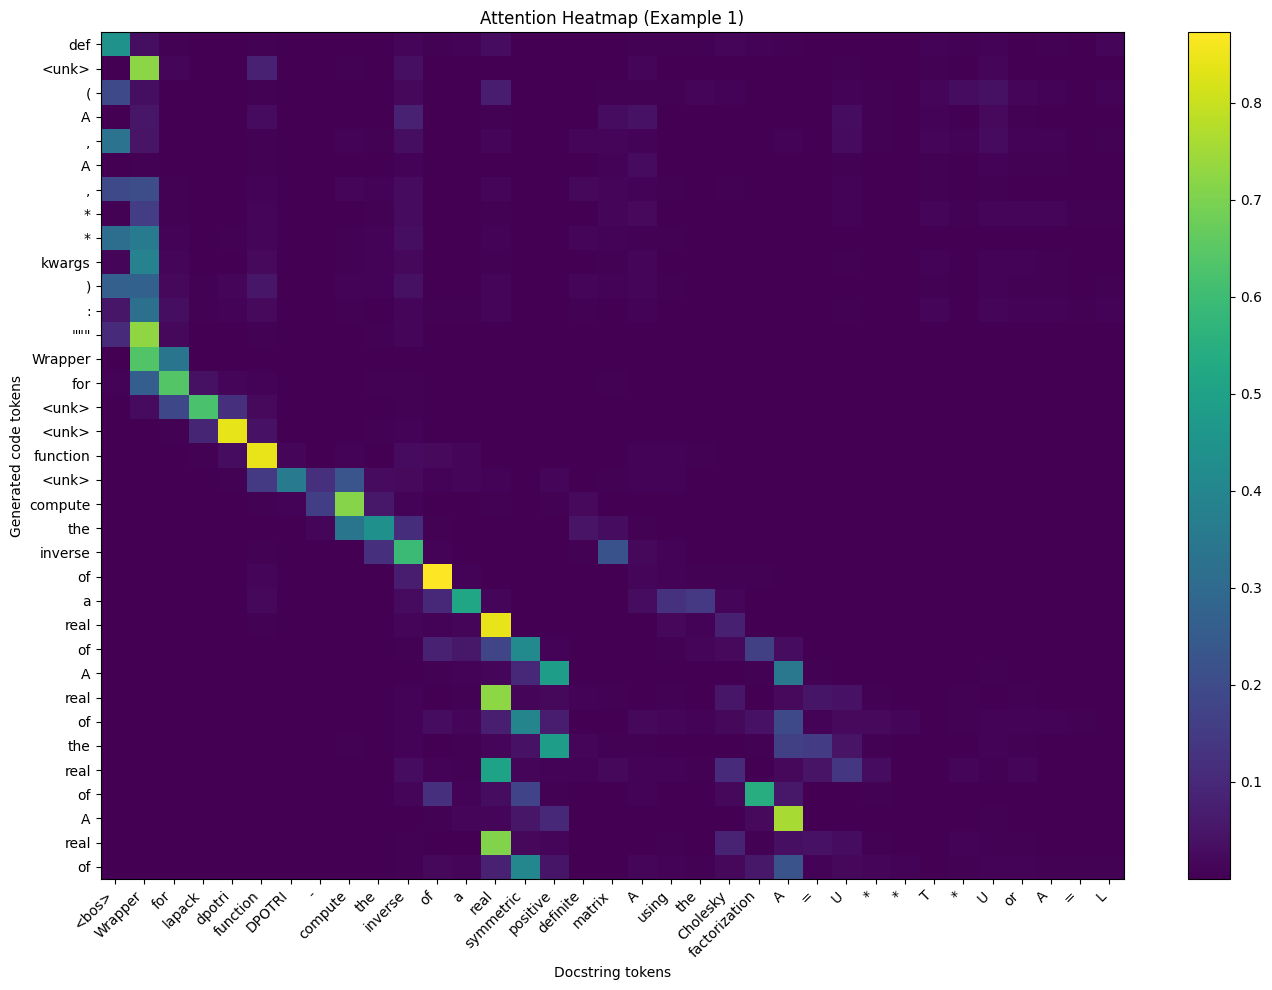


=== Example 2 ===
DOC: Creates a host template . @param name : Name of the host template to create . @return : An ApiHostTemplate object .
REF: def create_host_template ( self , name ) : """ Creates a host template . @param name : Name of the host template to create . @return : An ApiHostTemplate object . """ return host_templates . create_host_template ( self . _get_resource_root ( ) , name , self . name )
GEN: def <unk> ( self , name , : ) : """ Creates a host template . @param name : Name of the host template to create . @return : An <unk> object . """ if = . . . . . . . . . . . . . . . . . . . . . . . .


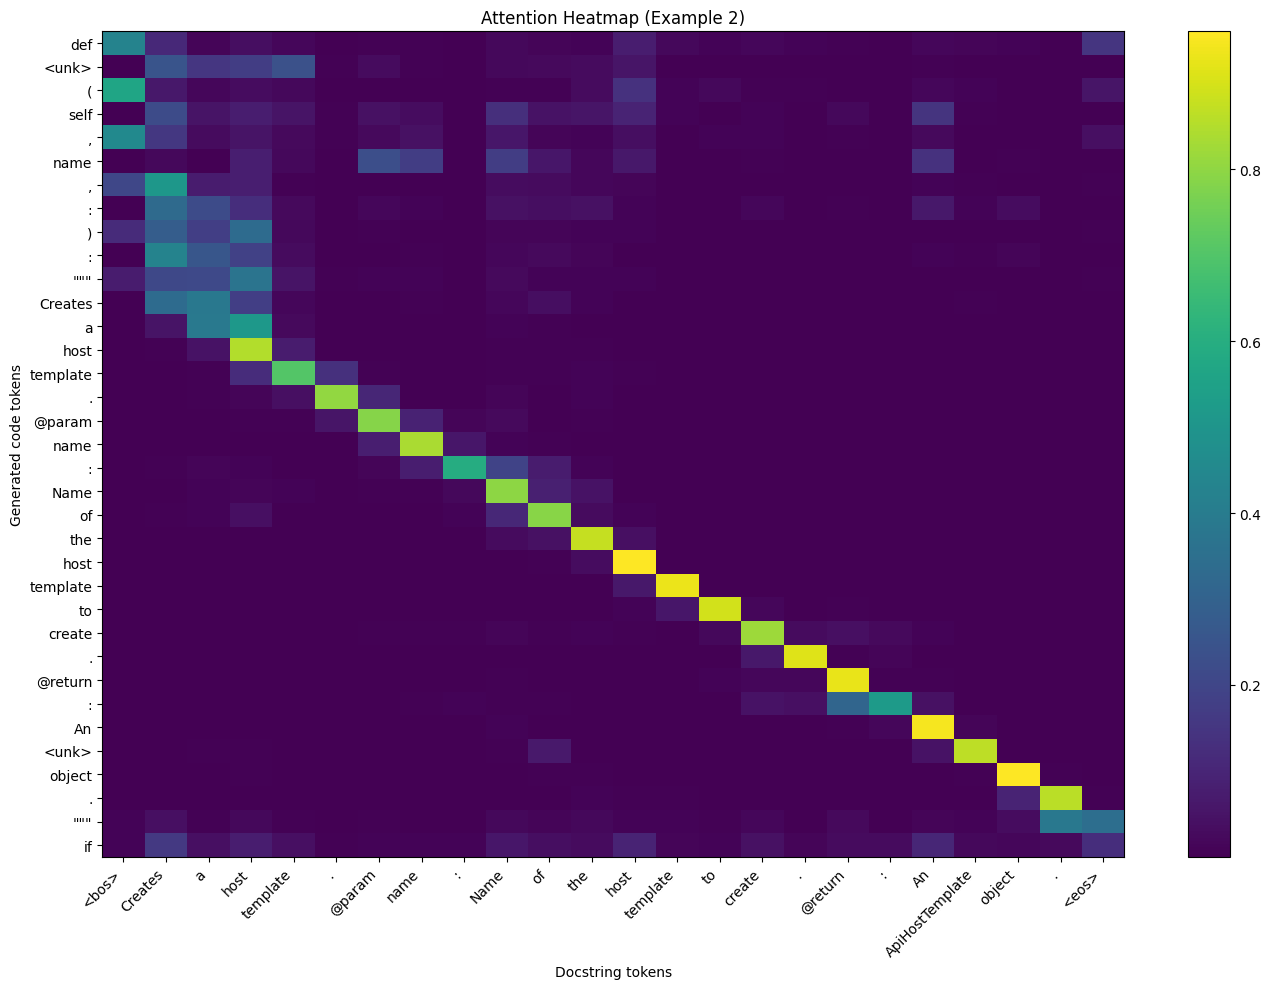


=== Example 3 ===
DOC: Reads the table header . Args : file_object ( file ) : file - like object . table_header_offset ( int ) : offset of the tables header relative to the start of the file . Returns : keychain_table_header : table header . Raises : ParseError : if the table header
REF: def _ReadTableHeader ( self , file_object , table_header_offset ) : """Reads the table header . Args : file_object ( file ) : file - like object . table_header_offset ( int ) : offset of the tables header relative to the start of the file . Returns : keychain_table_header : table header . Raises : ParseError : if the table header
GEN: def <unk> ( self , filename = None ) : """ Reads the table header . Args : es_fo ( file ) : file - like object . <unk> ( int ) : offset of the tables header relative to the start of the file . Returns : <unk> : header header . Raises : : : the header header


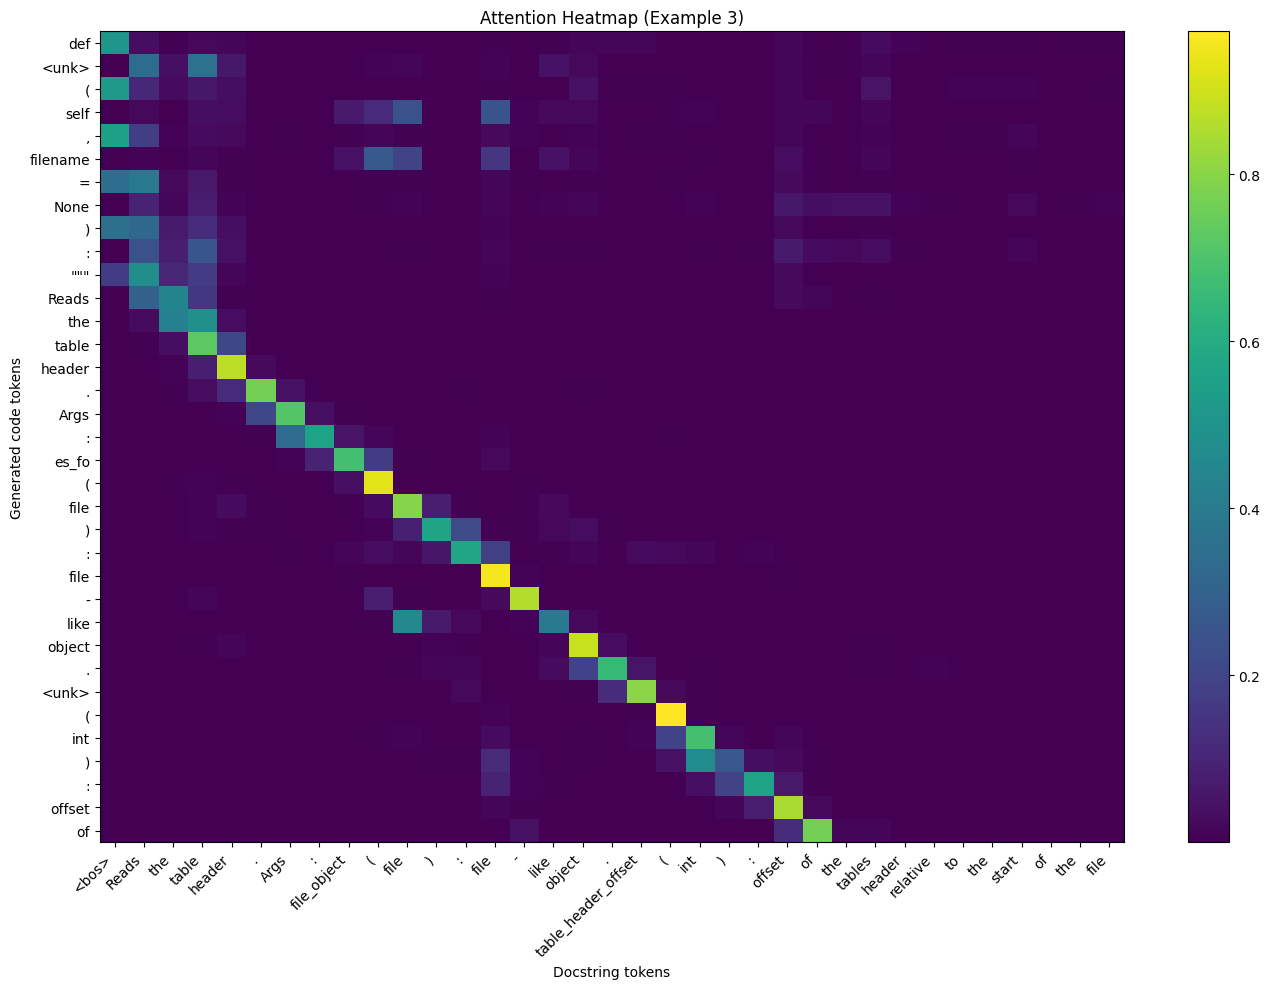

In [18]:
import matplotlib.pyplot as plt

@torch.no_grad()
def decode_with_attention(model: Seq2SeqAttn, src_tokens: List[str], max_len=60):
    """
    Returns:
      gen_tokens: List[str]
      src_tokens: List[str]
      attn_matrix: np.ndarray [Tgen, Tsrc]
    """
    model.eval()

    # encode source
    src_ids = src_vocab.encode(src_tokens, add_bos_eos=True, max_len=cfg.MAX_SRC_LEN+2)
    src = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)  # [1,S]
    src_lens = torch.tensor([len(src_ids)], dtype=torch.long, device=device)

    enc_out, enc_hidden = model.encoder(src, src_lens)   # enc_out [1,S,2H]
    hidden = model._init_hidden(enc_hidden)              # [1,1,H]
    src_mask = (src != src_vocab.stoi[PAD]).long()       # [1,S]

    inp = torch.tensor([tgt_vocab.stoi[BOS]], dtype=torch.long, device=device)
    gen_ids = []
    attn_rows = []

    for _ in range(max_len):
        logits, hidden, alpha = model.decoder(inp, hidden, enc_out, src_mask)
        nxt = logits.argmax(dim=-1)   # [1]
        gen_ids.append(int(nxt.item()))
        attn_rows.append(alpha.squeeze(0).detach().cpu().numpy())  # [S]
        inp = nxt

        if int(nxt.item()) == tgt_vocab.stoi[EOS]:
            break

    gen_tokens = tgt_vocab.decode(gen_ids, stop_eos=True)

    # source tokens shown on heatmap (exclude BOS/EOS for readability)
    src_display = [BOS] + src_tokens + [EOS]
    # Our src_ids already included BOS/EOS, so attention aligns to those ids.
    # Build an attention matrix aligned to src_display length:
    attn = np.stack(attn_rows, axis=0)  # [Tgen, S]

    # generated token display (same length as attention rows)
    gen_display = gen_tokens if len(gen_tokens) > 0 else ["(empty)"]

    return gen_display, src_display[:attn.shape[1]], attn[:, :len(src_display[:attn.shape[1]])]


def plot_attention_heatmap(gen_tokens, src_tokens, attn_matrix, title="Attention Heatmap"):
    plt.figure(figsize=(min(14, 0.6*len(src_tokens)+3), min(10, 0.35*len(gen_tokens)+3)))
    plt.imshow(attn_matrix, aspect="auto")
    plt.xticks(range(len(src_tokens)), src_tokens, rotation=45, ha="right")
    plt.yticks(range(len(gen_tokens)), gen_tokens)
    plt.xlabel("Docstring tokens")
    plt.ylabel("Generated code tokens")
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()


# ---- Pick 3 test samples and visualize ----
samples = random.sample(test_pairs, k=3)  # each item = (src_tokens, tgt_tokens)

for i, (src_toks, tgt_toks) in enumerate(samples, start=1):
    gen_toks, src_disp, attn = decode_with_attention(model_attn, src_toks, max_len=60)

    print(f"\n=== Example {i} ===")
    print("DOC:", " ".join(src_toks))
    print("REF:", " ".join(tgt_toks[:60]))
    print("GEN:", " ".join(gen_toks[:60]))

    plot_attention_heatmap(
        gen_toks[:min(len(gen_toks), 35)],
        src_disp[:min(len(src_disp), 35)],
        attn[:min(attn.shape[0], 35), :min(attn.shape[1], 35)],
        title=f"Attention Heatmap (Example {i})"
    )

In [19]:
import ast

def detokenize_code(tokens: List[str]) -> str:
    """
    Convert token list back to a code-ish string.
    This is approximate, but good enough for AST validation.
    """
    s = " ".join(tokens)
    # tighten spacing around common punctuation/operators for more parseable code
    s = re.sub(r"\s+([()\[\]{},.:])", r"\1", s)
    s = re.sub(r"([=+\-*/<>])\s+", r"\1", s)
    s = re.sub(r"\s+([=+\-*/<>])", r"\1", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

@torch.no_grad()
def ast_validity_rate(model, loader, max_decode_len=90, show_bad=5):
    model.eval()
    total = 0
    valid = 0
    bad_cases = []

    for src, src_lens, tgt, _ in loader:
        src, src_lens, tgt = src.to(device), src_lens.to(device), tgt.to(device)
        out = model.greedy_decode(src, src_lens, max_len=max_decode_len)

        for i in range(out.size(0)):
            gen_toks = tgt_vocab.decode(out[i].tolist(), stop_eos=True)
            code_str = detokenize_code(gen_toks)

            total += 1
            try:
                ast.parse(code_str)
                valid += 1
            except Exception as e:
                if len(bad_cases) < show_bad:
                    ref_toks = tgt_vocab.decode(tgt[i, 1:].tolist(), stop_eos=True)
                    bad_cases.append({
                        "error": str(e),
                        "gen": code_str[:400],
                        "ref": detokenize_code(ref_toks)[:400],
                    })

    rate = 100.0 * valid / max(1, total)
    return rate, bad_cases

# ---- Run AST validity on each model (bonus) ----
for m, name in [(model_rnn, "Vanilla RNN"), (model_lstm, "LSTM"), (model_attn, "LSTM + Attention")]:
    rate, bad = ast_validity_rate(m, test_loader, max_decode_len=cfg.MAX_DECODE_LEN, show_bad=3)
    print(f"\nAST Validity Rate [{name}]: {rate:.2f}%")
    if bad:
        print("Sample invalid generations:")
        for j, ex in enumerate(bad, start=1):
            print(f"\n  -- Bad Example {j} --")
            print("  Error:", ex["error"])
            print("  GEN :", ex["gen"])
            print("  REF :", ex["ref"])


AST Validity Rate [Vanilla RNN]: 0.00%
Sample invalid generations:

  -- Bad Example 1 --
  Error: unterminated triple-quoted string literal (detected at line 1) (<unknown>, line 1)
  GEN : def<unk>( self,:,:,: """: a<unk>of the..........:..:.::.::::::::::::::::::::::::::::::::::::::::::::::::::::::::
  REF : def<unk>( self): """ List of<unk>of announce URLs or ``None`` for no<unk>A tier is either a single announce URL(: class: `str`) or an: class: ` ~ collections. abc.<unk>( e. g.: class: `list`) of announce URLs. Setting this property sets or removes<unk>and<unk>-<unk>in: attr:<unk>.<unk>is set to the

  -- Bad Example 2 --
  Error: unterminated triple-quoted string literal (detected at line 1) (<unknown>, line 1)
  GEN : def<unk>( self,:,:,: """: a<unk>of the..........:..:.::.::::::::::::::::::::::::::::::::::::::::::::::::::::::::
  REF : def get_page( self,<unk>,<unk>=False): """ Get custom page for given relative url from filesystem. Possible input:-my-page/-my-page/index. html-

In [5]:
import ast

def detokenize_code(tokens: List[str]) -> str:
    """
    Convert token list back to a code-ish string.
    This is approximate, but good enough for AST validation.
    """
    s = " ".join(tokens)
    # tighten spacing around common punctuation/operators for more parseable code
    s = re.sub(r"\s+([()\[\]{},.:])", r"\1", s)
    s = re.sub(r"([=+\-*/<>])\s+", r"\1", s)
    s = re.sub(r"\s+([=+\-*/<>])", r"\1", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

@torch.no_grad()
def ast_validity_rate(model, loader, max_decode_len=90, show_bad=5):
    model.eval()
    total = 0
    valid = 0
    bad_cases = []

    for src, src_lens, tgt, _ in loader:
        src, src_lens, tgt = src.to(device), src_lens.to(device), tgt.to(device)
        out = model.greedy_decode(src, src_lens, max_len=max_decode_len)

        for i in range(out.size(0)):
            gen_toks = tgt_vocab.decode(out[i].tolist(), stop_eos=True)
            code_str = detokenize_code(gen_toks)

            total += 1
            try:
                ast.parse(code_str)
                valid += 1
            except Exception as e:
                if len(bad_cases) < show_bad:
                    ref_toks = tgt_vocab.decode(tgt[i, 1:].tolist(), stop_eos=True)
                    bad_cases.append({
                        "error": str(e),
                        "gen": code_str[:400],
                        "ref": detokenize_code(ref_toks)[:400],
                    })

    rate = 100.0 * valid / max(1, total)
    return rate, bad_cases

# ---- Run AST validity on each model (bonus) ----
for m, name in [(model_rnn, "Vanilla RNN"), (model_lstm, "LSTM"), (model_attn, "LSTM + Attention")]:
    rate, bad = ast_validity_rate(m, test_loader, max_decode_len=cfg.MAX_DECODE_LEN, show_bad=3)
    print(f"\nAST Validity Rate [{name}]: {rate:.2f}%")
    if bad:
        print("Sample invalid generations:")
        for j, ex in enumerate(bad, start=1):
            print(f"\n  -- Bad Example {j} --")
            print("  Error:", ex["error"])
            print("  GEN :", ex["gen"])
            print("  REF :", ex["ref"])

find: ‘/content/drive/MyDrive’: No such file or directory
